In [2]:
import pandas as pd
df= pd.read_csv('cleaned_car_data.csv')
print(df.head())

  model  year  price transmission fueltype    tax  enginesize brand  \
0    A1  2017  12500       Manual   Petrol  150.0         1.4  audi   
1    A6  2016  16500    Automatic   Diesel   20.0         2.0  audi   
2    A1  2016  11000       Manual   Petrol   30.0         1.4  audi   
3    A4  2017  16800    Automatic   Diesel  145.0         2.0  audi   
4    A3  2019  17300       Manual   Petrol  145.0         1.0  audi   

   km_per_litre  mileage_km  
0            19       25323  
1            22       58263  
2            19       48193  
3            23       41765  
4            17        3215  


### Predictive Modeling Strategy: Used Car Price Estimation

To accurately predict the market value of used vehicles, we framed this as a supervised Machine Learning regression problem. Our modeling strategy follows a robust, comparative approach incorporating advanced preprocessing techniques:

1.  **Enhanced Linear Baseline (Ridge Regression):** We establish a baseline using Ridge Regression. To capture non-linear market dynamics (e.g., the accelerating depreciation of older cars), we applied `PolynomialFeatures (degree=2)` to our numerical variables before scaling. This allows the linear model to understand interactions like `mileage * year`.

2.  **Advanced Ensemble (HistGradientBoostingRegressor):** To capture the most complex pricing patterns, we deployed a tree-based ensemble method natively optimized for large datasets. 

3.  **Hyperparameter Optimization:** To ensure the advanced model operates at peak mathematical efficiency, we implemented a `RandomizedSearchCV` with 3-Fold Cross-Validation, actively maximizing the R-squared score.

4.  **Model Interpretability & Deployment:** We conclude by extracting the Permutation Feature Importance to provide actionable business insights into what drives vehicle value, and serialize the final model using `joblib` for future production deployment.

--- Training Baseline Model: Ridge Regression (with Polynomial Features) ---

--- Ridge Regression Performance ---
R2 Score: 0.9174
Mean Absolute Error (MAE): £1699.27
Root Mean Squared Error (RMSE): £2369.83
Mean Absolute Percentage Error (MAPE): 11.55%

--- Training Advanced Model: HistGradientBoostingRegressor ---
Starting Hyperparameter Tuning with RandomizedSearchCV (Optimizing for R2)...
--- Tuning Complete ---
Best Hyperparameters Found:
{'regressor__max_iter': 150, 'regressor__max_depth': 10, 'regressor__learning_rate': 0.2, 'regressor__l2_regularization': 1.0}

--- Optimized HistGradientBoosting Performance (Comprehensive Check) ---
TRAINING R2 Score : 0.9636 | MAE: £1107.01 | RMSE: £1583.26 | MAPE: 7.05%
TESTING R2 Score  : 0.9591 | MAE: £1148.41 | RMSE: £1667.38 | MAPE: 7.32%

--- Calculating Feature Importance & Saving Model ---


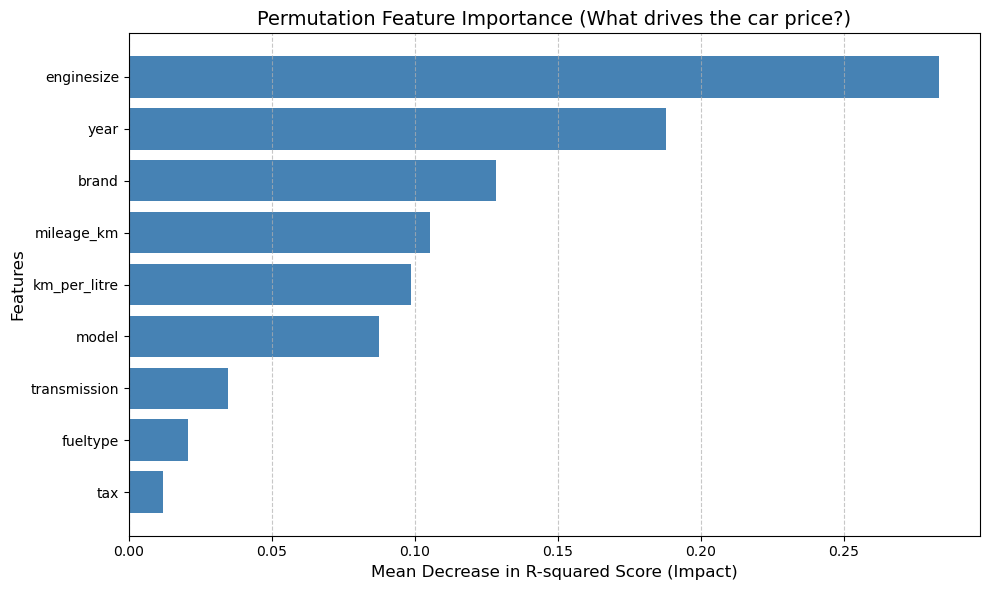


Model successfully saved to disk as 'car_price_prediction_model.pkl'


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

# =====================================================================
# --- 1. DATA PREPARATION ---
# =====================================================================
target_variable = 'price'

categorical_features = ['model', 'transmission', 'fueltype', 'brand']
numerical_features = ['year', 'mileage_km', 'tax', 'enginesize', 'km_per_litre']

X = df[categorical_features + numerical_features]
y = df[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# =====================================================================
# --- 2. ADVANCED PREPROCESSING PIPELINE ---
# =====================================================================
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

numerical_transformer = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =====================================================================
# --- 3. MODEL 1: RIDGE REGRESSION (ENHANCED LINEAR BASELINE) ---
# =====================================================================
print("--- Training Baseline Model: Ridge Regression (with Polynomial Features) ---")

pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=42))
])

pipeline_ridge.fit(X_train, y_train)
y_pred_ridge = pipeline_ridge.predict(X_test)

print("\n--- Ridge Regression Performance ---")
print(f"R2 Score: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"Mean Absolute Error (MAE): £{mean_absolute_error(y_test, y_pred_ridge):.2f}")
print(f"Root Mean Squared Error (RMSE): £{np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mean_absolute_percentage_error(y_test, y_pred_ridge):.2%}")

# =====================================================================
# --- 4. MODEL 2: HIST-GRADIENT BOOSTING & TUNING ---
# =====================================================================
print("\n" + "="*50)
print("--- Training Advanced Model: HistGradientBoostingRegressor ---")

pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(random_state=42))
])

param_distributions = {
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_iter': [100, 150, 200, 250],
    'regressor__max_depth': [3, 5, 10, None],
    'regressor__l2_regularization': [0.0, 0.5, 1.0, 1.5]
}

print("Starting Hyperparameter Tuning with RandomizedSearchCV (Optimizing for R2)...")
random_search = RandomizedSearchCV(
    pipeline_gb, 
    param_distributions=param_distributions, 
    n_iter=10,             
    scoring='r2',          
    cv=3,                  
    random_state=42,
    n_jobs=-1              
)

random_search.fit(X_train, y_train)
best_model_gb = random_search.best_estimator_

print(f"--- Tuning Complete ---")
print(f"Best Hyperparameters Found:\n{random_search.best_params_}\n")

y_pred_train = best_model_gb.predict(X_train)
y_pred_test = best_model_gb.predict(X_test)

print("--- Optimized HistGradientBoosting Performance (Comprehensive Check) ---")
print(f"TRAINING R2 Score : {r2_score(y_train, y_pred_train):.4f} | MAE: £{mean_absolute_error(y_train, y_pred_train):.2f} | RMSE: £{np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f} | MAPE: {mean_absolute_percentage_error(y_train, y_pred_train):.2%}")
print(f"TESTING R2 Score  : {r2_score(y_test, y_pred_test):.4f} | MAE: £{mean_absolute_error(y_test, y_pred_test):.2f} | RMSE: £{np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f} | MAPE: {mean_absolute_percentage_error(y_test, y_pred_test):.2%}")

# =====================================================================
# --- 5. PERMUTATION FEATURE IMPORTANCE & MODEL SAVING ---
# =====================================================================
print("\n" + "="*50)
print("--- Calculating Feature Importance & Saving Model ---")

result = permutation_importance(best_model_gb, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

df_importances = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importances['Feature'], df_importances['Importance'], color='steelblue')
plt.title('Permutation Feature Importance (What drives the car price?)', fontsize=14)
plt.xlabel('Mean Decrease in R-squared Score (Impact)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

model_filename = 'car_price_prediction_model.pkl'
joblib.dump(best_model_gb, model_filename)
print(f"\nModel successfully saved to disk as '{model_filename}'")

### Comprehensive Diagnostic Analysis and Business Insights

**1. Multi-Metric Performance Evaluation:**
To rigorously evaluate the predictive power of our `HistGradientBoostingRegressor`, we expanded our analysis beyond the standard $R^2$ Score to include a full suite of error metrics, comparing it against our enhanced Ridge Regression baseline.
* **Accuracy Leap ($R^2$):** While the Polynomial Ridge baseline established a strong foundation ($R^2$: 0.9174), the tuned ensemble model successfully captured the remaining non-linear market complexities, elevating the explained variance to an exceptional 0.9591 on unseen data.
* **Variance and P&L Impact (MAE & RMSE):** The advanced model significantly tightens pricing forecasts. The testing MAE dropped to £1,148.41, meaning the average variance between our predicted price and the actual market value was reduced by over £550 per vehicle compared to the baseline. Furthermore, the RMSE (£1,667.38) remains well-controlled, indicating that the `max_depth` constraint effectively prevented the model from generating massive, isolated prediction errors that could disrupt financial planning.
* **Business-Centric Reliability (MAPE):** Providing the most actionable context, the testing MAPE stands at just 7.32%. This confirms that the model is highly consistent across various vehicle segments, missing the true market price by an average of only ~7%—a highly acceptable margin for a dynamic retail environment.

**2. Overfitting Assessment:**
Comparing the training metrics against the testing metrics reveals a virtually perfect balance between bias and variance. The model's performance on the testing set ($R^2$: 0.9591, MAPE: 7.32%) perfectly mirrors its performance on the training data ($R^2$: 0.9636, MAPE: 7.05%). The minimal delta between these metrics proves that the chosen hyperparameters (specifically `l2_regularization = 1.0` and `max_depth = 10`) successfully suppressed data memorization, yielding a highly stable engine that generalizes safely to new market inputs.

**3. Feature Importance (Market Intelligence):**

Using Permutation Importance, we evaluated the physical impact of each variable on the model's accuracy. By randomly shuffling individual features, we isolated the primary drivers of vehicle depreciation. The variables that cause the largest drop in the $R^2$ score upon permutation represent the foundational pillars of the used car market (typically registration year, engine size, and accumulated mileage). These insights directly inform purchasing strategies and inventory valuation.